# Regresi Linear

In [1]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


## Data Preparation

In [2]:
# Data Preparation
df = pd.read_excel("../Data Final/Final_PM14.xlsx")

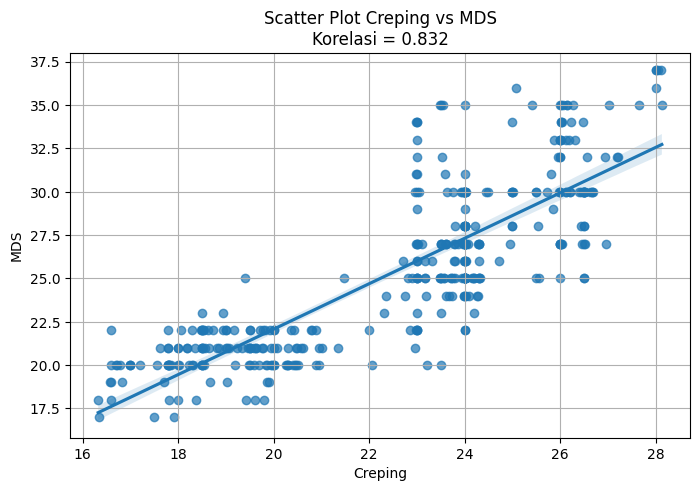

In [8]:
# Hitung korelasi Pearson
corr = df['Mean_Creping'].corr(df['MDS'])

# Plot
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Mean_Creping'],
    y=df['MDS'],
    scatter_kws={'alpha':0.7}
)

plt.title(f'Scatter Plot Creping vs MDS\nKorelasi = {corr:.3f}')
plt.xlabel('Creping')
plt.ylabel('MDS')

plt.grid(True)
plt.show()

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 386 entries, 7 to 884
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Start_Time               386 non-null    datetime64[us]
 1   End_Time                 386 non-null    datetime64[us]
 2   Data_Count               386 non-null    int64         
 3   Mean_Creping             386 non-null    float64       
 4   Mean_Yankee Speed        386 non-null    float64       
 5   Mean_Pope Reel Speed     386 non-null    float64       
 6   Mean_Yankee Pressure     386 non-null    float64       
 7   Mean_Stock Flow          386 non-null    float64       
 8   Mean_Stock Consistency   386 non-null    float64       
 9   Mean_Flow Coating        386 non-null    float64       
 10  Mean_Flow Release        386 non-null    float64       
 11  Mean_Jet Wire Ratio      386 non-null    float64       
 12  Mean_Load KWH Refiner    386 non-null    float64    

In [5]:
high_mds = (df['MDS'] > 50).sum()
print(high_mds)

24


In [6]:
# Data Preparation
df = df[df['MDS'] <= 40]

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)


## Modelling Linear Regression

In [9]:
# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']

# X Variables
features = [
    'Mean_Yankee Pressure',
    'Mean_Creping',
    '% NBKP',
    'Mean_Load KWH Refiner',
    'Mean_Jet Wire Ratio',
    'GSM',
    'coating_release_ratio',
    'pseudo_mass'
]

In [10]:
# X Variables
X = df[features]

# Y Variables
target = 'MDS'
y = df[target]

In [11]:
# BACKWARD ELIMINATION
selected_features = features.copy()

while True:
    X_model = sm.add_constant(df[selected_features])
    model = sm.OLS(y, X_model).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    if max_p > 0.05:
        remove_feature = p_values.idxmax()
        print(f"Menghapus: {remove_feature} (p-value = {max_p:.4f})")
        selected_features.remove(remove_feature)
    else:
        break

# MODEL FINAL

print("\n===== FEATURE TERPILIH =====")
print(selected_features)

print("\n===== SUMMARY MODEL FINAL =====")
print(model.summary())

Menghapus: Mean_Load KWH Refiner (p-value = 0.1520)
Menghapus: coating_release_ratio (p-value = 0.0833)

===== FEATURE TERPILIH =====
['Mean_Yankee Pressure', 'Mean_Creping', '% NBKP', 'Mean_Jet Wire Ratio', 'GSM', 'pseudo_mass']

===== SUMMARY MODEL FINAL =====
                            OLS Regression Results                            
Dep. Variable:                    MDS   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     359.5
Date:                Fri, 22 May 2026   Prob (F-statistic):          4.84e-153
Time:                        09:35:14   Log-Likelihood:                -782.90
No. Observations:                 386   AIC:                             1580.
Df Residuals:                     379   BIC:                             1608.
Df Model:                           6                                         
Covariance Type:          

### Import Model

In [ ]:
import joblib
import os

# Folder model
os.makedirs("models/PM14/MDS", exist_ok=True)

# Simpan model
joblib.dump(model_no_const, "models/PM14/MDS/model.pkl")

# Simpan fitur
joblib.dump(features, "models/PM14/MDS/features.pkl")

print("Model berhasil disimpan!")

## Pemeriksaan Asumsi IIDN

### Independen (Autokorelasi)

In [12]:
DW = sm.stats.durbin_watson(model.resid)
print('Nilai DW =', DW)
if DW > 1.5 and DW < 2.5:
    print('Tidak ada autokorelasi (baik positif maupun negatif)')
elif DW < 1.5:
    print('Terdapat autokorelasi positif.')
elif DW > 2.5:
    print('Terdapat autokorelasi negatif.')

Nilai DW = 1.138682902582862
Terdapat autokorelasi positif.


### Indentik (Heterokesdastisitas)

In [13]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan Test
# H0: Homoskedastisitas (Varians konstan)
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(37.86293346210578), 'LM-Test p-value': np.float64(1.1948374565871858e-06), 'F-Statistic': np.float64(6.869924311155432), 'F-Test p-value': np.float64(6.159165484282285e-07)}


Terjadi Heteroskedastisitas yang parah pada model. Varians dari residual terbukti secara empiris tidak konstan.

### Normalitas

In [14]:
# Libraries
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

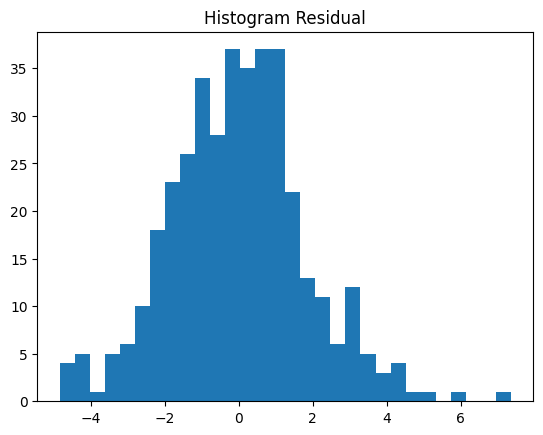

In [15]:
# Histogram
plt.figure()
plt.hist(model.resid, bins=30)
plt.title("Histogram Residual")
plt.show()

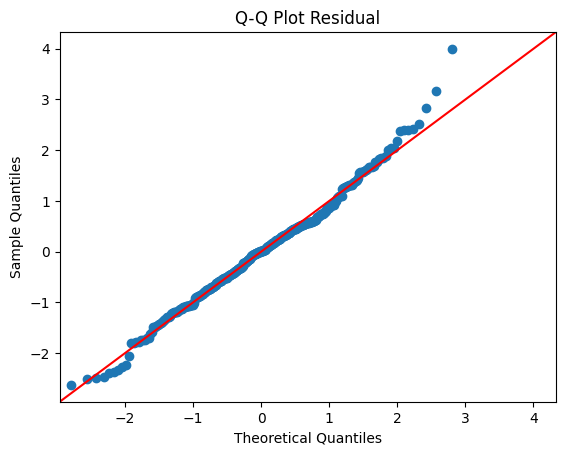

In [16]:
# Visualisasi (Q-Q Plot)
sm.qqplot(model.resid, line='45', fit=True)
plt.title("Q-Q Plot Residual")
plt.show()

In [17]:
# Uji Statistik (Shapiro-Wilk)
# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

stat, p_value = stats.shapiro(model.resid)

# Jika p-value < 0.05, residual tidak berdistribusi normal
print(f"Shapiro-Wilk Test: p-value = {p_value}")
if p_value < 0.05:
    print('residual tidak berdistribusi normal')
else:
    print('residual berdistribusi normal.')

Shapiro-Wilk Test: p-value = 0.01927163338774587
residual tidak berdistribusi normal


### Multikolinearitas

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

                 Feature          VIF
0   Mean_Yankee Pressure  8828.896591
1           Mean_Creping   249.590914
2                 % NBKP   111.950813
3  Mean_Load KWH Refiner   474.241791
4    Mean_Jet Wire Ratio  7940.953475
5                    GSM   739.899093
6  coating_release_ratio   330.301217
7            pseudo_mass  2159.142190
